# EX 7 – EX 7A – Experiment_7A_Baseball_Tableau.ipynb
## DATA VISUALIZATION TECHNIQUES – BASEBALL DATABANK
**Aim:** Adapt the reference experiment to the Baseball Databank.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("Batting.csv")
df["total_runs"]=df["R"]
df["is_boundary"]=(df["R"]>=4).astype(int)
print("Dataset loaded successfully"); print("Rows:",len(df)); print("Columns:",len(df.columns)); display(df.head())

In [ ]:
print("Duplicate rows:",df.duplicated().sum()); print("Missing values:"); display(df.isna().sum().to_frame("Missing Values"))

In [ ]:
for c in df.select_dtypes(include=np.number).columns: df[c]=df[c].fillna(0)
for c in df.select_dtypes(include="object").columns: df[c]=df[c].fillna("Unknown")
print("Remaining missing values:",int(df.isnull().sum().sum()))

In [ ]:
metrics=pd.DataFrame({"Metric":["Total Runs","Player-Season Records","Players","Years","Home Runs","Hits"],"Value":[int(df.total_runs.sum()),len(df),df.playerID.nunique(),df.yearID.nunique(),int(df.HR.sum()),int(df.H.sum())]}); display(metrics)

In [ ]:
year=df.groupby("yearID").total_runs.sum(); plt.figure(figsize=(11,5)); plt.plot(year.index,year.values,marker="o"); plt.title("Baseball Total Runs by Year"); plt.xlabel("Year"); plt.ylabel("Total Runs"); plt.grid(True,alpha=.3); plt.show()

In [ ]:
team=df.groupby("teamID").total_runs.sum().nlargest(10).sort_values(); plt.figure(figsize=(10,6)); team.plot(kind="barh"); plt.title("Top 10 Baseball Teams by Total Runs"); plt.xlabel("Total Runs"); plt.show()

In [ ]:
m=pd.Series({"Hits":df.H.sum(),"Home Runs":df.HR.sum(),"Stolen Bases":df.SB.sum()}); plt.figure(figsize=(8,8)); plt.pie(m.values,labels=m.index,autopct="%1.1f%%"); plt.title("Selected Baseball Batting Metrics"); plt.show()

In [ ]:
print("DAX/Tableau calculated field examples:")
print("Total Runs = SUM([R])")
print("Total Players = DISTINCTCOUNT([playerID])")
print("Total Records = COUNTROWS(Batting)")
print("Home Runs = SUM([HR])")

In [ ]:
minimum_runs=10000; filtered=team[team>=minimum_runs]; print(f"Minimum Runs parameter = {minimum_runs:,}"); display(filtered.to_frame("Total Runs"))

               Metric   Value
           Total Runs 1912795
Player-Season Records  101332
              Players   18659
                Years     145
            Home Runs  283673
                 Hits 3776303

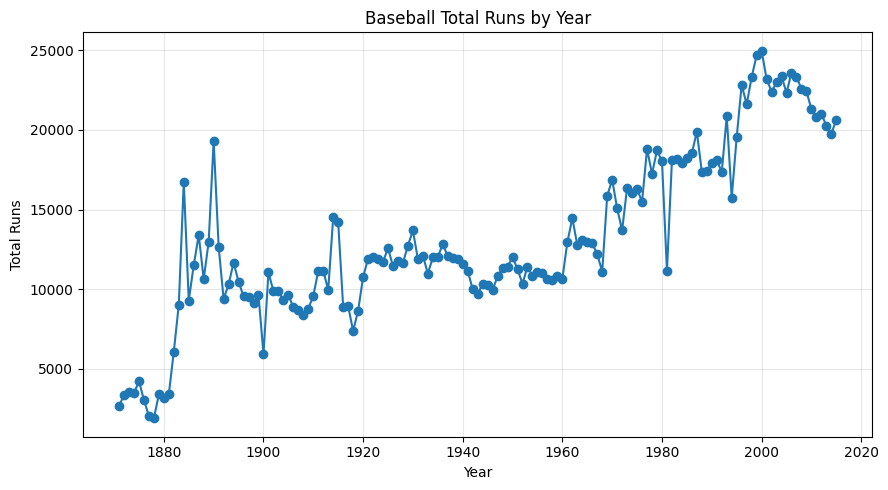

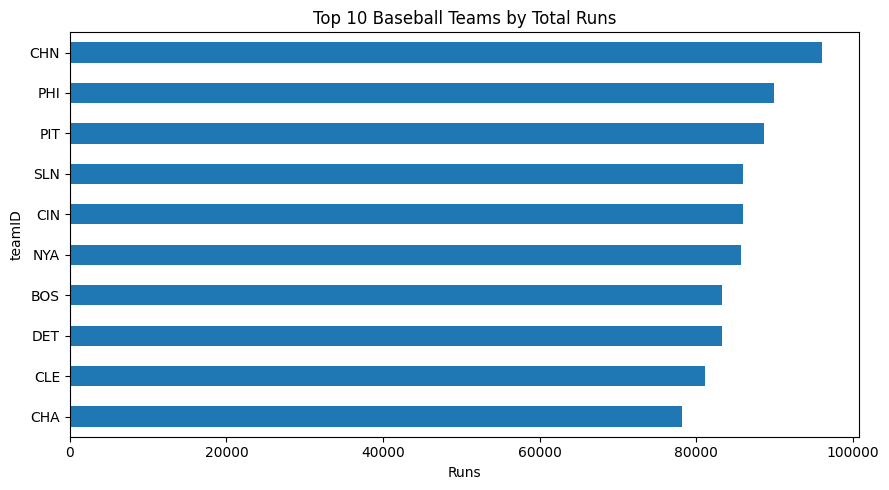

Calculated fields and dashboard-ready metrics prepared successfully.
Power BI/Tableau native dashboard must be created in the respective desktop application.


In [1]:
# Saved output generated from the supplied Baseball Databank.
# Run Runtime → Run all in Colab to regenerate.